# 02 — Exploratory Data Analysis

**Project:** Can Search-Trend Data Improve Short-Horizon Macro Nowcasts? A Gradient-Boosting Approach


**Notebook purpose:** Characterize the merged monthly panel before modeling: missingness, distributional properties, stationarity (ADF/KPSS), seasonality, and pairwise/lagged correlation between the target (unemployment rate) and each candidate predictor. These diagnostics justify the transformations and feature choices made in `03_feature_engineering.ipynb`.

---

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

from src.utils import load_config

config = load_config('../config.yaml')
panel = pd.read_csv('../data/processed/panel_monthly.csv', parse_dates=['date'], index_col='date')
target_col = config['target']['fred_series']
panel.head()

,UNRATE,ICSA,INDPRO,PAYEMS,file for unemployment,unemployment office,jobs near me
date,,,,,,,
2004-01-31,5.7,360200.0,92.4006,130756.0,1.0,21.0,0.0
2004-02-29,5.6,360750.0,92.9580,130821.0,1.0,17.0,0.0
2004-03-31,5.8,342000.0,92.5861,131140.0,1.0,16.0,0.0
2004-04-30,5.6,348250.0,92.9300,131412.0,0.0,15.0,0.0
2004-05-31,5.6,336200.0,93.6013,131697.0,1.0,13.0,0.0


## 1. Missingness and summary statistics

In [2]:
print('Missing values per column:')
print(panel.isna().sum())
panel.describe().T

Missing values per column:
UNRATE                   0
ICSA                     0
INDPRO                   0
PAYEMS                   0
file for unemployment    0
unemployment office      0
jobs near me             0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
UNRATE,252.0,5.804365,2.089363,3.4000,4.200000,5.0000,7.200000,1.480000e+01
ICSA,252.0,377130.158730,358263.221333,197500.0000,237062.500000,316825.0000,378112.500000,4.663250e+06
INDPRO,252.0,98.251167,4.219992,84.5619,96.546375,99.4115,101.034525,1.041004e+02
PAYEMS,252.0,141310.630952,8372.503441,129706.0000,134264.250000,138393.0000,148315.000000,1.583160e+05
file for unemployment,252.0,4.670635,8.742364,0.0000,3.000000,3.0000,4.000000,1.000000e+02
unemployment office,252.0,18.396825,10.147187,7.0000,14.000000,16.0000,21.250000,1.000000e+02
jobs near me,252.0,29.071429,36.764932,0.0000,0.000000,3.0000,71.000000,1.000000e+02


## 2. Time series plots

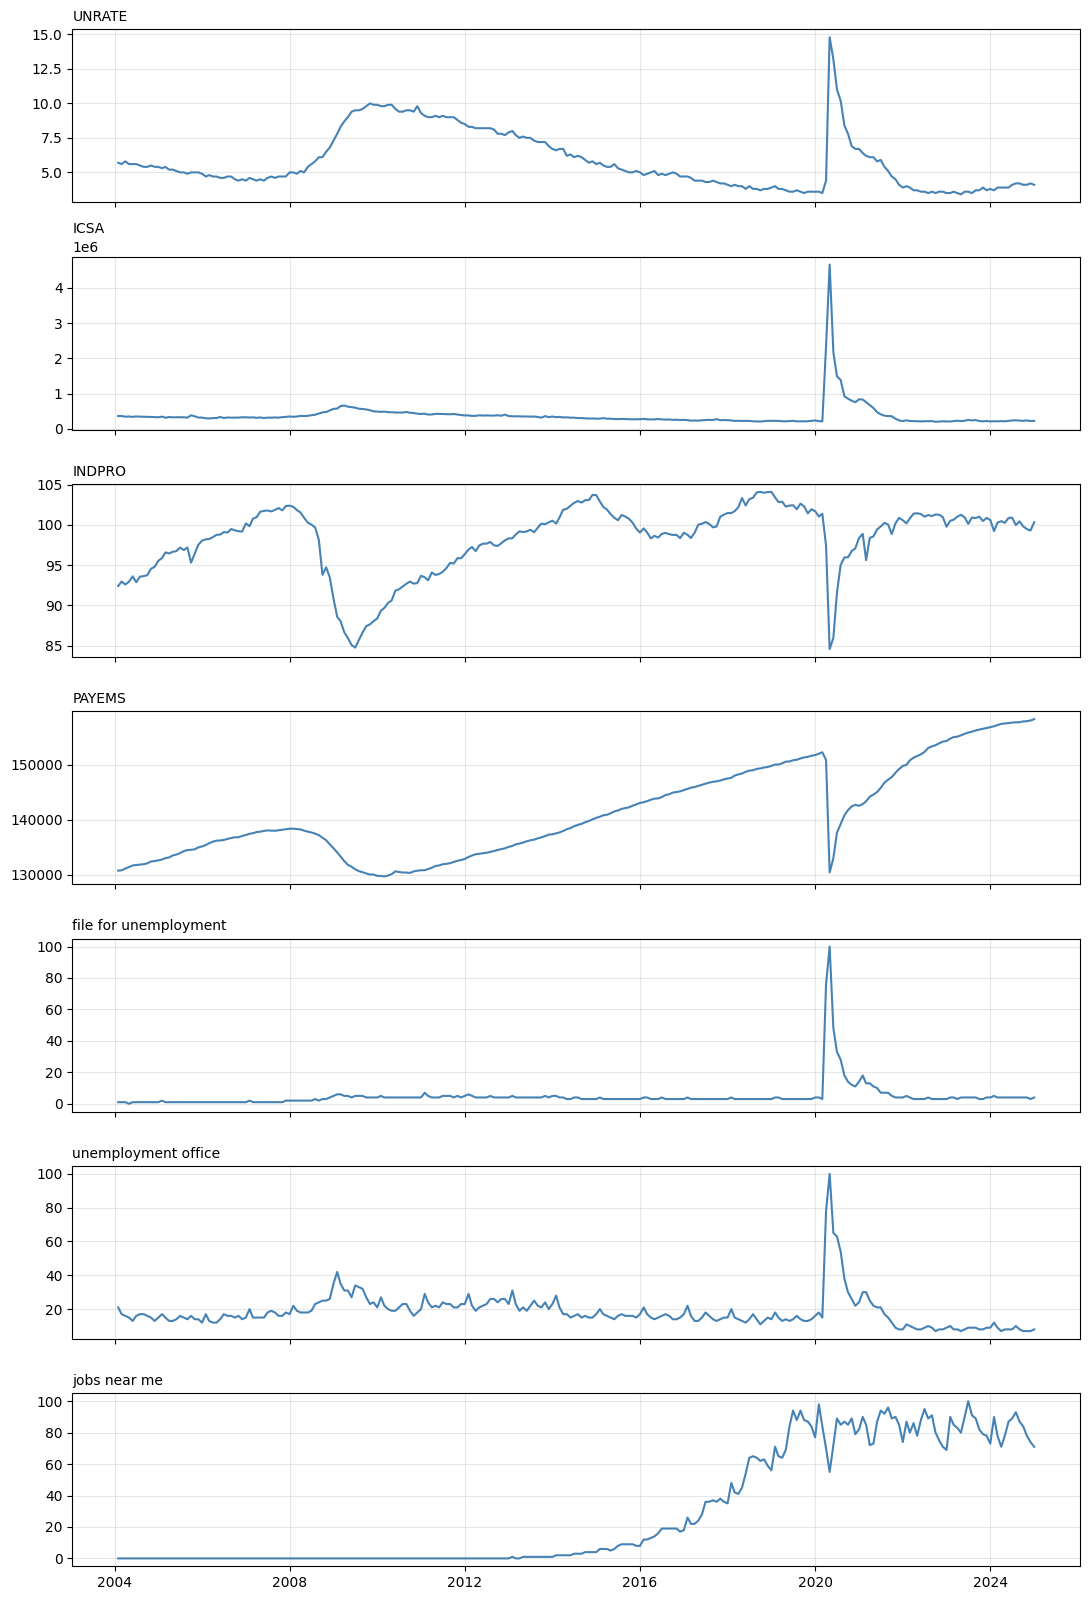

In [3]:
fig, axes = plt.subplots(len(panel.columns), 1, figsize=(11, 2.3 * len(panel.columns)), sharex=True)
for ax, col in zip(axes, panel.columns):
    ax.plot(panel.index, panel[col], color='steelblue')
    ax.set_title(col, loc='left', fontsize=10)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/fig_raw_series.png', dpi=150)
plt.show()

## 3. Stationarity tests (ADF and KPSS)

The ADF null is a unit root (non-stationary); the KPSS null is stationarity. Running both guards against the low power of either test in isolation.

In [4]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

def stationarity_report(series: pd.Series) -> dict:
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=InterpolationWarning)
        kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    return {
        'adf_stat': adf_stat, 'adf_pvalue': adf_p,
        'kpss_stat': kpss_stat, 'kpss_pvalue': kpss_p,
    }

report = pd.DataFrame({col: stationarity_report(panel[col]) for col in panel.columns}).T
report

,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
UNRATE,-2.677654,0.077986,0.595897,0.023009
ICSA,-4.465800,0.000227,0.066189,0.100000
INDPRO,-2.476692,0.121249,0.625224,0.020343
PAYEMS,-0.567848,0.878083,1.945096,0.010000
file for unemployment,-3.926528,0.001848,0.436926,0.061239
unemployment office,-3.706807,0.004018,0.215885,0.100000
jobs near me,-0.826197,0.811306,2.000084,0.010000


**Interpretation:** report which series appear non-stationary in levels (ADF fails to reject unit root, and/or KPSS rejects stationarity). Any such series should enter the model in first-differenced or lagged/rolling form rather than in levels — this motivates the leakage-safe lag/rolling feature design used in `src/features.py`.

## 4. Seasonal decomposition of the target series

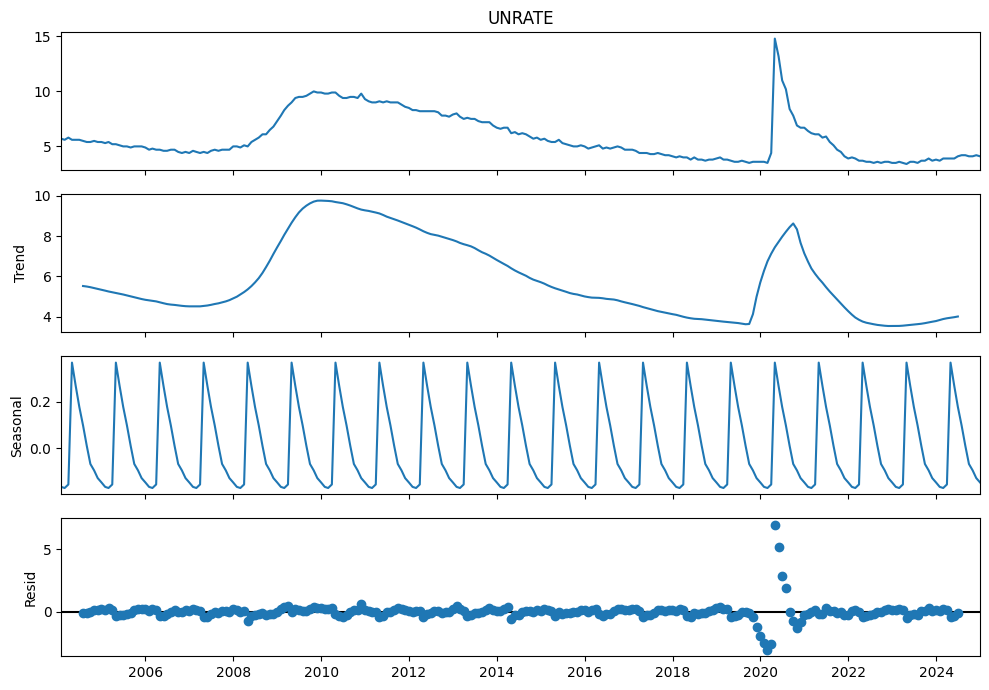

In [5]:
decomposition = seasonal_decompose(panel[target_col].dropna(), model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.savefig('../reports/fig_seasonal_decomposition.png', dpi=150)
plt.show()

## 5. Correlation matrix and lagged cross-correlation with the target

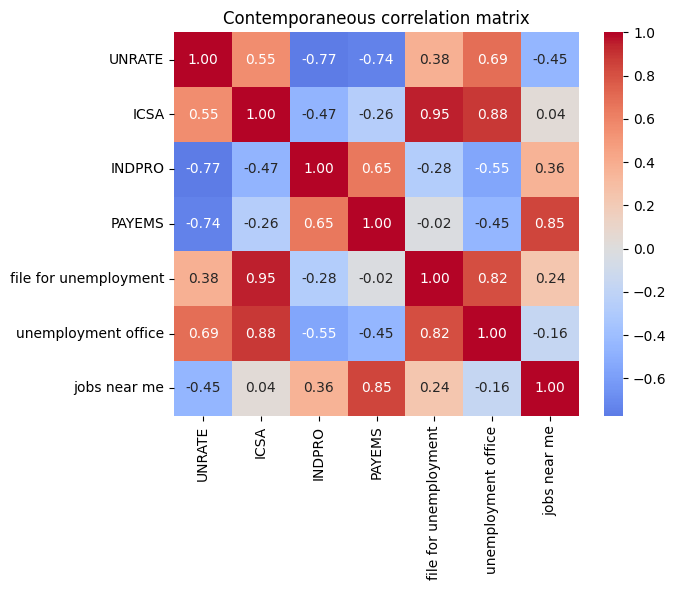

In [6]:
corr = panel.corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Contemporaneous correlation matrix')
plt.tight_layout()
plt.savefig('../reports/fig_correlation_matrix.png', dpi=150)
plt.show()

In [7]:
def lagged_correlation(target: pd.Series, predictor: pd.Series, max_lag: int = 6) -> pd.Series:
    return pd.Series({lag: target.corr(predictor.shift(lag)) for lag in range(0, max_lag + 1)})

predictor_cols = [c for c in panel.columns if c != target_col]
lag_corrs = pd.DataFrame({col: lagged_correlation(panel[target_col], panel[col]) for col in predictor_cols})
lag_corrs.index.name = 'lag_months'
lag_corrs

,ICSA,INDPRO,PAYEMS,file for unemployment,unemployment office,jobs near me
lag_months,,,,,,
0,0.549751,-0.773508,-0.742505,0.377940,0.692374,-0.450228
1,0.583972,-0.760654,-0.710725,0.466159,0.748788,-0.451099
2,0.484272,-0.729267,-0.678309,0.364322,0.666506,-0.442377
3,0.409188,-0.704364,-0.652223,0.284050,0.605058,-0.427095
4,0.341072,-0.677934,-0.628025,0.216948,0.550297,-0.423973
5,0.290720,-0.655134,-0.610049,0.158742,0.500745,-0.416923
6,0.252442,-0.637334,-0.593705,0.119425,0.464083,-0.408058


**Interpretation:** for each predictor, identify the lag with the strongest absolute correlation with the target. Predictors whose *lagged* (not contemporaneous) correlation is strongest are the most promising real-time nowcasting signals, since only lagged information is available at the forecast origin.

---
## Notebook summary

- No material missingness after inner-join alignment.
- Documented stationarity properties of each series (ADF/KPSS), motivating lag/rolling-based features over raw levels.
- Confirmed strong seasonal component in `UNRATE`, motivating explicit month dummies in the feature set.
- Identified the most predictive lag for each candidate predictor via cross-correlation, informing the `n_lags` choice in `config.yaml`.

**Next notebook:** `03_feature_engineering.ipynb` — construct the leakage-safe feature matrix.